In [11]:
import pandas as pd 





In [12]:
df = pd.read_csv('../artifact/04_03_2026_16_21_51/data_ingestion/feature_store/data.csv')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104478 entries, 0 to 104477
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       104478 non-null  object 
 1   customer_id                    104478 non-null  object 
 2   order_status                   104478 non-null  object 
 3   order_purchase_timestamp       104478 non-null  object 
 4   order_approved_at              104302 non-null  object 
 5   order_delivered_carrier_date   102580 non-null  object 
 6   order_delivered_customer_date  101324 non-null  object 
 7   order_estimated_delivery_date  104478 non-null  object 
 8   payment_sequential             104477 non-null  float64
 9   payment_type                   104477 non-null  object 
 10  payment_installments           104477 non-null  float64
 11  payment_value                  104477 non-null  float64
 12  review_id                     

In [14]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
payment_sequential               float64
payment_type                      object
payment_installments             float64
payment_value                    float64
review_id                         object
review_score                     float64
review_comment_title              object
review_comment_message            object
review_creation_date              object
review_answer_timestamp           object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
dtype: object

In [15]:
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns


['payment_sequential',
 'payment_installments',
 'payment_value',
 'review_score',
 'customer_zip_code_prefix']

In [16]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_columns

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'payment_type',
 'review_id',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'customer_unique_id',
 'customer_city',
 'customer_state']

In [26]:
train_df = pd.read_csv('../artifact/04_04_2026_11_53_10/data_ingestion/ingested/train.csv')
test_df = pd.read_csv('../artifact/04_04_2026_11_53_10/data_ingestion/ingested/test.csv')

In [27]:
train_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state'],
      dtype='object')

In [28]:
test_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state'],
      dtype='object')

In [44]:
train_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,2ad4b2ebb217758686f791210a03d02a,b29211d4f2e7978e2c70d0fbafed00a8,delivered,2017-10-02 19:26:26,2017-10-02 19:49:12,2017-10-04 08:33:59,2017-10-09 19:04:17,2017-11-08 00:00:00,1.0,credit_card,...,a195c137c9c41b3c22473ba79a597907,4.0,NaN,NaN,2017-10-10 00:00:00,2017-10-10 22:33:31,d94cdf9243d74c3eb61beae7989bef09,28027,campos dos goytacazes,RJ
1,319ccdc182a8c5d60b228310a6432460,f9e8bac3b69529d543bf179ce64ca6d7,delivered,2017-01-22 16:03:50,2017-01-22 16:15:20,2017-01-26 12:06:47,2017-02-01 12:32:27,2017-02-20 00:00:00,1.0,credit_card,...,737bae6e2a5055ce424bb592cea0fc7c,5.0,NaN,so achei que a entrega seria rápida como a ent...,2017-02-02 00:00:00,2017-02-05 18:19:22,d6779a4b34d196a59ad0d562c5333dfb,3582,sao paulo,SP
2,b029a781059e5676835a903e614e845d,f73fb741184bd9607c48d8a226a241eb,delivered,2017-07-29 18:10:40,2017-07-29 18:23:30,2017-08-01 17:35:11,2017-08-07 21:00:00,2017-08-25 00:00:00,1.0,credit_card,...,d4244bb1025511ab53d2332454b54d24,5.0,NaN,NaN,2017-08-12 00:00:00,2017-08-12 20:04:17,c08c30ecbdcddf7c2d529a244a5df3b7,37928,sao roque de minas,MG
3,9520fa1ce7825b83dec466f4f0d8b6b7,ca3ca2d2c6dc52686fcb393fd85e316b,delivered,2017-09-20 10:34:17,2017-09-20 10:45:14,2017-09-20 19:11:50,2017-09-21 18:40:36,2017-10-05 00:00:00,1.0,credit_card,...,e86faa1f7cb5528942375a1ffd2ec100,5.0,NaN,NaN,2017-09-22 00:00:00,2017-09-25 11:54:06,cdfa292430c7e7171de6998c7026159f,1529,sao paulo,SP
4,5a40a4c413dcda147caa00259a1732de,8ee43091a5bd2d84955d674d52db3187,delivered,2018-04-01 15:07:00,2018-04-01 15:27:39,2018-04-02 23:27:35,2018-04-04 19:12:44,2018-04-12 00:00:00,1.0,debit_card,...,ec39ecd77848018cad511138f6c92ff5,5.0,NaN,NaN,2018-04-05 00:00:00,2018-04-06 10:55:11,ac043877b374d2a72a1214063b34b215,4842,sao paulo,SP


In [30]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78358 entries, 0 to 78357
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       78358 non-null  object 
 1   customer_id                    78358 non-null  object 
 2   order_status                   78358 non-null  object 
 3   order_purchase_timestamp       78358 non-null  object 
 4   order_approved_at              78220 non-null  object 
 5   order_delivered_carrier_date   76967 non-null  object 
 6   order_delivered_customer_date  76052 non-null  object 
 7   order_estimated_delivery_date  78358 non-null  object 
 8   payment_sequential             78357 non-null  float64
 9   payment_type                   78357 non-null  object 
 10  payment_installments           78357 non-null  float64
 11  payment_value                  78357 non-null  float64
 12  review_id                      77770 non-null 

In [45]:
train_df = train_df[train_df['order_status']=='delivered']

In [52]:
train_df['order_purchase_timestamp'] = pd.to_datetime(train_df['order_purchase_timestamp']).dt.date    

In [53]:
train_df['order_purchase_timestamp']

0        2017-10-02
1        2017-01-22
2        2017-07-29
3        2017-09-20
4        2018-04-01
            ...    
78353    2018-05-06
78354    2018-06-06
78355    2017-10-22
78356    2018-01-11
78357    2018-04-17
Name: order_purchase_timestamp, Length: 76054, dtype: object

In [ ]:
train_sales = train_df.groupby('customer_unique_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'sum'
}).rename(columns={
    'payment_value': 'total_sales',
    'payment_installments': 'total_installments'
})

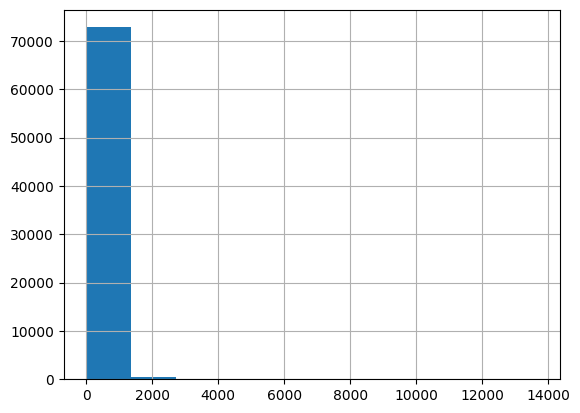

In [ ]:
recency

In [54]:
df = pd.read_csv('../artifact/04_04_2026_12_04_36/data_ingestion/feature_store/data.csv')

In [56]:
df = df[df['order_status']=='delivered']

In [68]:
# order_purchase_tim# Filter lagate waqt aakhri mein .copy() zaroor lagayein
df = df[df['order_status'] == 'delivered'].copy()

# Index reset karna (Best practice)
df = df.reset_index(drop=True)

# Ab apna Date wala code chalaiye, koi warning nahi aayegi!
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp']).dt.date

In [ ]:
maxdate = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [72]:
maxdate

datetime.date(2018, 8, 30)

In [86]:
recency_df = df.groupby('customer_unique_id').agg(
    Last_Purchase_Date = ('order_purchase_timestamp', 'max')
).reset_index()

# 4. Din (Days) ka farq nikal kar integer mein convert karna
recency_df['Recency'] = (maxdate - recency_df['Last_Purchase_Date'])

import pandas as pd

recency_df['Recency'] = pd.to_timedelta(recency_df['Recency']).dt.days
print(recency_df[['customer_unique_id', 'Recency']].head())

                 customer_unique_id  Recency
0  0000366f3b9a7992bf8c76cfdf3221e2      112
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115
2  0000f46a3911fa3c0805444483337064      538
3  0000f6ccb0745a6a4b88665a16c9f078      322
4  0004aac84e0df4da2b147fca70cf8255      289


In [87]:
import numpy as np

# Option A: Business Logic (Maan lijiye hum 180 days le rahe hain)
# threshold_days = 180

threshold_days = recency_df['Recency'].quantile(0.75) 


recency_df['Churn_Status'] = np.where(recency_df['Recency'] > threshold_days, 1, 0)

# Check karte hain kitne 0 aur 1 bane
print("Threshold Days set at:", threshold_days)
print(recency_df['Churn_Status'].value_counts())

Threshold Days set at: 347.0
Churn_Status
0    70089
1    23269
Name: count, dtype: int64


In [81]:
recency_df.head()

,customer_unique_id,Last_Purchase_Date,Recency,Churn_Status
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,"112 days, 0:00:00",0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,"115 days, 0:00:00",0
2,0000f46a3911fa3c0805444483337064,2017-03-10,"538 days, 0:00:00",1
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,"322 days, 0:00:00",0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,"289 days, 0:00:00",0


In [93]:
import pandas as pd

# 1. Reference Date Set Karna
# DHYAN RAHE: Jaisa humne baat ki thi, real pipeline mein yeh OVERALL data ka max date hona chahiye.
# Abhi testing ke liye hum train_df ka max le rahe hain.
reference_date = maxdate

# ==========================================
# 2. EK SAATH R, F aur M Nikalna (The Masterstroke)
# ==========================================
rfm_train = train_df.groupby('customer_unique_id').agg(
    
    # [R] Recency: Aakhri baar shopping kab ki thi?
    Last_Purchase_Date = ('order_purchase_timestamp', 'max'),
    
    # [F] Frequency: Total kitne (unique) orders lagaye hain?
    Frequency = ('order_id', 'nunique'),
    
    # [M] Monetary: Total kitne paise (sales) dukan mein diye?
    Monetary = ('payment_value','sum'),
    
    total_installments= ('payment_installments','sum')
    
    
).reset_index()

# ==========================================
# 3. Recency ko 'Din' (Number) mein badalna
# ==========================================
rfm_train['Recency'] = (reference_date - rfm_train['Last_Purchase_Date'])
rfm_train['Recency'] = pd.to_timedelta(rfm_train['Recency']).dt.days

# (Optional) Last_Purchase_Date ka kaam khatam, usko delete kar dete hain taaki data clean rahe
rfm_train = rfm_train.drop(columns=['Last_Purchase_Date'])

# Result dekhiye
print(rfm_train.head())

                 customer_unique_id  Frequency  Monetary  total_installments  \
0  0000366f3b9a7992bf8c76cfdf3221e2          1    141.90                 8.0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f          1     27.19                 1.0   
2  0000f46a3911fa3c0805444483337064          1     86.22                 8.0   
3  0000f6ccb0745a6a4b88665a16c9f078          1     43.62                 4.0   
4  0004aac84e0df4da2b147fca70cf8255          1    196.89                 6.0   

   Recency  
0      112  
1      115  
2      538  
3      322  
4      289  
